In [1]:
from aeon.benchmarking.published_results import load_classification_bake_off_2023_results
from aeon.visualisation import plot_critical_difference
import polars as pl
import numpy as np
from aeon.datasets.tsc_datasets import univariate
from tscglue import utils
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
directory = "figures"
Path(directory).mkdir(parents=True, exist_ok=True)

In [3]:
from tscglue.utils import load_s3_parquet_cached

res_mine = load_s3_parquet_cached()
res_mine

100%|██████████| 19/19 [00:00<00:00, 25.76it/s]


dataset,model,fold,test_accuracy
str,str,i64,f64
"""InsectEPGRegularTrain""","""loky-stacker-v10-rstsf-random""",11,1.0
"""PigArtPressure""","""multirocket-f32""",20,0.927885
"""BirdChicken""","""loky-stacker-v7-soft-rf""",0,0.9
"""Herring""","""multistack-best-stacking""",28,0.609375
"""RefrigerationDevices""","""loky-stacker-v8-base-r1""",22,0.786667
…,…,…,…
"""ProximalPhalanxOutlineAgeGroup""","""loky-stacker-v9-base-r2""",12,0.858537
"""GunPointMaleVersusFemale""","""loky-stacker-v8-auto-best""",10,1.0
"""StarLightCurves""","""loky-stacker-v10-rstsf-random""",21,0.98288


In [4]:
res_mine = res_mine.filter(
    (pl.col("model").str.contains("loky-stacker-v5")) == False
).filter(
    pl.col("model").str.starts_with("ablation-") == False
)

In [5]:
results_arr, datasets, classifiers = load_classification_bake_off_2023_results(
    num_resamples=30, as_array=True
)
results_arr.shape

(112, 34)

In [6]:
#v = res_mine.filter(pl.col('fold')==5).pivot(values="test_accuracy", index="dataset", on="model").select(['dataset', 'loky-stacker-v7', 'loky-stacker-v6'])
#v.with_columns((pl.col('loky-stacker-v7') - pl.col('loky-stacker-v6')).alias('diff')).sort('diff', descending=True)

In [7]:
pivoted = res_mine.pivot(values="test_accuracy", index="dataset", on="model", aggregate_function='len')
numeric_cols = [c for c in pivoted.columns if c != "dataset"]
sum_row = pl.DataFrame([{"dataset": "all", **{c: pivoted[c].sum() for c in numeric_cols}}]).with_columns([
    pl.col(c).cast(pl.UInt32) for c in numeric_cols
])
result = pl.concat([pivoted, sum_row])
result

dataset,loky-stacker-v10-rstsf-random,multirocket-f32,loky-stacker-v7-soft-rf,multistack-best-stacking,loky-stacker-v8-base-r1,loky-stacker-v10-base-r3,loky-stacker-v10-tabicl,multistack-ridgecv,multirocket-f16,mr-hydra-contained-auto,mr-hydra-kbest-5000,mycatch22v2,mycatch22,TSCGlue-17-4-26,loky-stacker-v6-soft-ridge,loky-stacker-v6,mr-hydra-kbest-auto,loky-stacker-v10-fm,loky-stacker-v6-soft-et,tabicl,multirocket-f64,loky-stacker-v8-auto-best-base,mymrhydrav2,loky-stacker-v8-base,rstsf-unsupervised,loky-stacker-v10-base,chronos2-ridgecv,mydummy,loky-stacker-v8-base-r3,multirocket-grp,loky-stacker-v7,loky-stacker-v8-auto-best-stacking,chronos2,mr-hydra-kbest-10000,mantis+chronos2+diff-ridgecv,loky-stacker-v10-base-2x,mantis+chronos2-ridgecv,rstsf-combined,loky-stacker-v6-soft-rf,rstsf-random,loky-stacker-v7-soft-filter-ridge,rstsf-random-ridge,multistack-best,loky-stacker-v7-soft-et,loky-stacker-v10-base-5x,mr-hydra-kbest-30000,loky-stacker-v7-soft-ridge,loky-stacker-v9-base-r2,loky-stacker-v8-auto-best,TSCGlue-3-3-26,mymrhydra,multistack-best-base,rstsf-unsupervised-raw,loky-stacker-v9-base-r1,loky-stacker-v10-fm-tsfresh,rstsf-unsupervised-ridge,loky-stacker-v9-base-r3,hivecotev2-1h-j8,rstsf-combined-ridge,hivecotev2-4h-j8,mantis+chronos2-rf
str,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
"""InsectEPGRegularTrain""",30,30,30,29,30,30,29,21,30,30,30,30,30,30,30,30,30,30,30,15,30,30,30,30,23,30,30,30,19,30,30,30,20,30,30,30,30,22,30,30,30,30,23,30,30,30,30,16,30,30,30,22,11,30,6,10,2,3,0,0,1
"""PigArtPressure""",30,30,30,28,30,30,30,18,30,30,30,30,30,30,30,30,30,30,30,23,30,30,30,30,15,30,30,30,18,30,30,30,18,30,30,30,30,18,30,30,30,30,26,30,29,30,30,18,30,30,30,25,11,30,4,9,3,3,0,1,0
"""BirdChicken""",30,30,30,28,30,30,30,20,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,20,30,30,30,18,30,30,30,23,30,30,30,30,27,30,30,30,30,29,30,29,30,30,20,30,30,30,22,11,30,7,15,2,6,1,1,0
"""Herring""",30,30,30,27,30,30,30,18,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,15,30,30,30,17,30,30,30,20,30,30,30,30,25,30,30,30,30,22,30,30,30,30,20,30,30,30,25,11,30,4,12,3,2,1,0,1
"""RefrigerationDevices""",30,30,30,30,30,30,30,20,30,30,30,30,30,30,30,30,30,30,30,27,30,30,30,30,21,30,30,30,22,30,30,30,22,30,30,30,30,21,30,30,30,30,26,30,30,30,30,19,30,30,30,23,14,30,7,9,2,4,0,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ToeSegmentation1""",30,30,30,28,30,30,30,19,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,21,30,30,30,19,30,30,30,21,30,30,30,30,22,30,30,30,30,28,30,29,30,30,16,30,30,30,24,15,30,6,10,3,4,2,0,0
"""UMD""",30,30,30,30,30,30,30,21,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,18,30,30,30,22,30,30,30,23,30,30,30,30,21,30,30,30,30,22,30,29,30,30,18,30,30,30,26,7,30,3,11,1,2,1,0,0
"""DistalPhalanxOutlineCorrect""",30,30,30,29,30,30,30,19,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,23,30,30,30,21,30,30,30,22,30,30,29,30,24,30,30,30,30,28,30,27,30,30,22,30,30,30,24,12,30,7,17,2,3,0,0,0


In [8]:
result.select(['dataset', 'hivecotev2-1h-j8']).sort('hivecotev2-1h-j8')

dataset,hivecotev2-1h-j8
str,u32
"""HandOutlines""",0
"""GunPointAgeSpan""",1
"""ToeSegmentation2""",1
"""SonyAIBORobotSurface2""",1
"""Herring""",2
…,…
"""FaceAll""",6
"""SemgHandGenderCh2""",7
"""Lightning7""",8


In [9]:
mine_classifiers = res_mine['model'].unique().to_list()

In [10]:
df_performance = pl.DataFrame(results_arr, schema=classifiers).with_columns(pl.Series("dataset", datasets))
df_performance_mine = res_mine.pivot(values="test_accuracy", index="dataset", on="model", aggregate_function='mean')
df_performance_full = df_performance.join(other=df_performance_mine, on='dataset')

In [11]:
df_performance_full = df_performance_full#.drop(mine_classifiers)
len(df_performance_full)

112

In [12]:
df_performance_full_saved = df_performance_full
df_performance_full = df_performance_full.drop([col for col in df_performance_full.columns if df_performance_full[col].null_count() > 0])

In [13]:
drop_models = ['ShapeDTW', 'EE', 'ResNet', 'CNN', 
               'CIF', 'BOSS', 'TSFresh', 'Arsenal', 
               'HC1', 'Hydra', '1NN-DTW', 'ROCKET', 
               'Mini-R', 'WEASEL-D', 'InceptionT', 'Signatures', 'RISE', 'DrCIF', 'TDE', 
               #'loky-stacker-v5-soft-et',
               #'loky-stacker-v5-soft-ridge',	
               #'loky-stacker-v5-soft-rf',	
               #'loky-stacker-v5-r1',
               'loky-stacker-v6',
               'loky-stacker-v6-soft-ridge',
               'loky-stacker-v6-soft-et',
               'loky-stacker-v6-soft-rf',
               'mymrhydra', 'mymrhydrav2',
               'mr-hydra-kbest-5000',
               'mr-hydra-kbest-10000',
               'mr-hydra-kbest-30000',
                'mycatch22v2', 'mycatch22',
                'mr-hydra-contained-auto',
                'mr-hydra-kbest-auto',
                'loky-stacker-v7',
                'loky-stacker-v7-soft-ridge',
                'loky-stacker-v7-soft-rf',
                'loky-stacker-v7-soft-et',
                'mydummy',
                'loky-stacker-v8-auto-best',
                'loky-stacker-v8-auto-best-base',
                'loky-stacker-v8-auto-best',


                'loky-stacker-v8-base',
                'loky-stacker-v8-base-r1',
                'loky-stacker-v8-base-r3',

                'multirocket-f16',
                'multirocket-f32',
                'multirocket-f64',

                'chronos2-ridgecv',
                'chronos2',
                'loky-stacker-v8-auto-best-stacking',
                'mantis+chronos2+diff-ridgecv',
                'mantis+chronos2-ridgecv',
]

In [14]:
df_performance_full = df_performance_full.drop(drop_models)

In [15]:
df_performance_full.columns

['Catch22',
 'FreshPRINCE',
 'HC2',
 'Hydra-MR',
 'MrSQM',
 'Multi-R',
 'PF',
 'RDST',
 'RSF',
 'RSTSF',
 'STC',
 'TS-CHIEF',
 'TSF',
 'WEASEL',
 'cBOSS',
 'dataset',
 'loky-stacker-v10-rstsf-random',
 'multistack-best-stacking',
 'loky-stacker-v10-base-r3',
 'loky-stacker-v10-tabicl',
 'multistack-ridgecv',
 'TSCGlue-17-4-26',
 'loky-stacker-v10-fm',
 'tabicl',
 'rstsf-unsupervised',
 'loky-stacker-v10-base',
 'multirocket-grp',
 'loky-stacker-v10-base-2x',
 'rstsf-combined',
 'rstsf-random',
 'loky-stacker-v7-soft-filter-ridge',
 'rstsf-random-ridge',
 'multistack-best',
 'loky-stacker-v10-base-5x',
 'TSCGlue-3-3-26',
 'multistack-best-base',
 'rstsf-unsupervised-raw',
 'loky-stacker-v9-base-r1',
 'loky-stacker-v10-fm-tsfresh']

/home/petelin/TSCGlue/.venv/lib/python3.13/site-packages/aeon/visualisation/results/_critical_difference.py:217: UserWarning: Estimators TSCGlue-17-4-26 and loky-stacker-v10-rstsf-random have the same performanceon all datasets. This may cause problems when forming cliques.
  p_values = wilcoxon_test(ordered_scores, ordered_labels, lower_better)


(<Figure size 600x570 with 1 Axes>, <Axes: >)

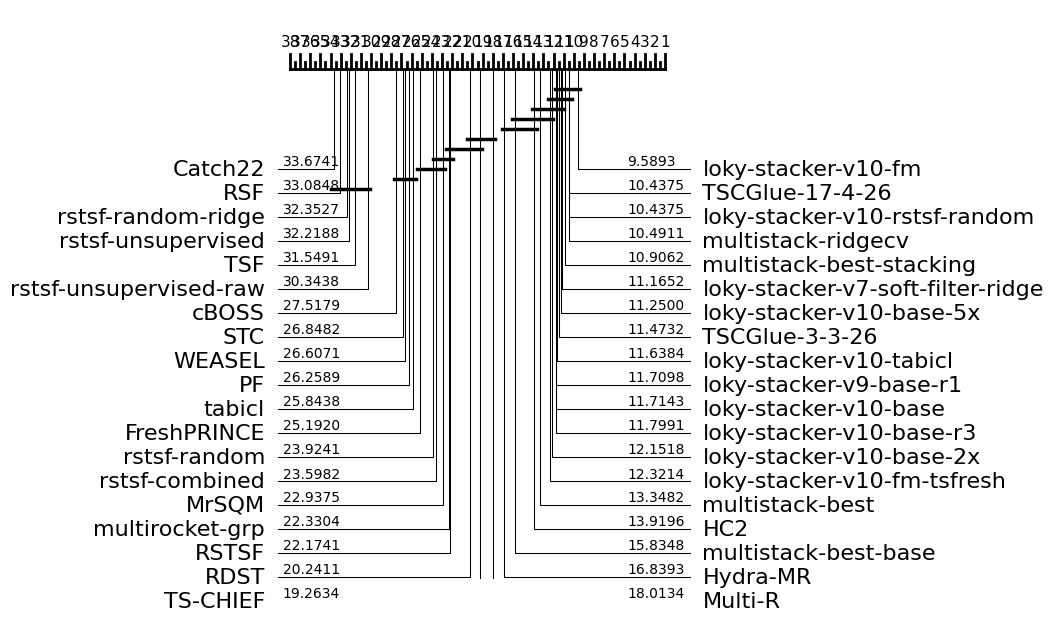

In [16]:
clsf = df_performance_full.select([c for c in df_performance_full.columns if c != "dataset"])
plot_critical_difference(clsf.to_numpy(), clsf.columns)

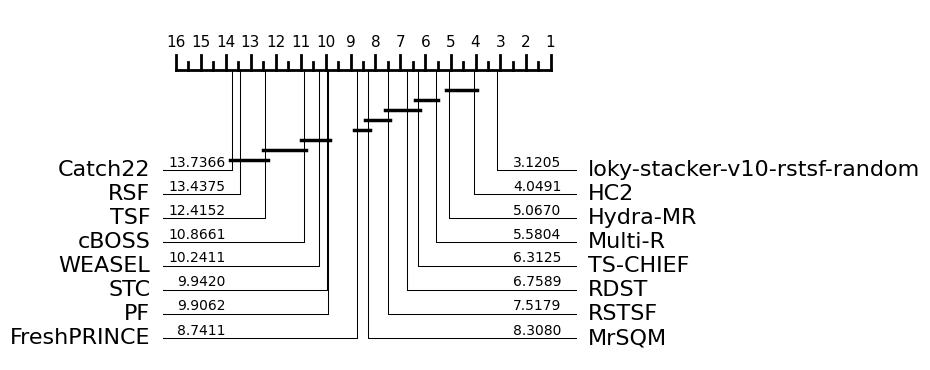

In [17]:
clsf = df_performance_full.select([
    c for c in df_performance_full.columns if c != "dataset" and (c in classifiers or c == 'loky-stacker-v10-rstsf-random')
])
plot_critical_difference(clsf.to_numpy(), clsf.columns)
plt.savefig(f"{directory}/critical_difference.pdf", bbox_inches='tight', pad_inches=0)


(<Figure size 600x350 with 1 Axes>, <Axes: >)

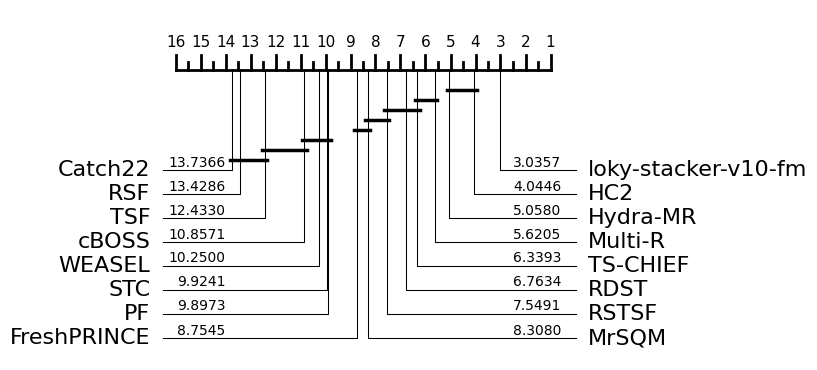

In [18]:
clsf = df_performance_full.select([
    c for c in df_performance_full.columns if c != "dataset" and (c in classifiers or c == 'loky-stacker-v10-fm')
])
plot_critical_difference(clsf.to_numpy(), clsf.columns)
#plt.savefig(f"{directory}/critical_difference.pdf", bbox_inches='tight', pad_inches=0)


In [19]:
clsf

Catch22,FreshPRINCE,HC2,Hydra-MR,MrSQM,Multi-R,PF,RDST,RSF,RSTSF,STC,TS-CHIEF,TSF,WEASEL,cBOSS,loky-stacker-v10-fm
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.996653,1.0,1.0,1.0,0.968139,1.0,1.0,1.0,1.0,1.0,0.976841,1.0,1.0,1.0,1.0,1.0
0.886538,0.870513,0.979327,0.926923,0.973878,0.926603,0.715705,0.932372,0.801603,0.865865,0.908333,0.96891,0.392468,0.978365,0.965705,0.935417
0.888333,0.923333,0.946667,0.91,0.958333,0.89,0.903333,0.913333,0.833333,0.963333,0.915,0.963333,0.821667,0.906667,0.981667,0.961667
0.553646,0.6015625,0.632292,0.630729,0.6421875,0.611458,0.574479,0.638021,0.578125,0.590104,0.6421875,0.597396,0.607292,0.627083,0.586458,0.6015625
0.705422,0.747467,0.827022,0.748533,0.785067,0.737778,0.672356,0.750222,0.666489,0.728444,0.787378,0.726844,0.615911,0.724267,0.794756,0.786578
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.856603,0.871778,0.928621,0.903967,0.919169,0.903222,0.914963,0.931763,0.859824,0.909372,0.888525,0.930112,0.858653,0.919196,0.89803,0.926784
0.820029,0.854386,0.954532,0.931433,0.954825,0.928509,0.835526,0.949123,0.905848,0.873099,0.95,0.959795,0.661257,0.940497,0.940351,0.958187
0.880093,0.982407,0.987731,0.985185,0.91713,0.980093,0.954398,0.974769,0.727546,0.959491,0.926157,0.983333,0.806944,0.969907,0.904398,0.991667


In [20]:
#clsf = df_performance_full.select(['loky-stacker-v6-soft-ridge', 'HC2', 'Hydra-MR', 'cBOSS', 'Catch22', 'RDST', 'WEASEL'])
#plot_critical_difference(clsf.to_numpy(), clsf.columns)

In [21]:
#clsf = df_performance_full.select(['loky-stacker-v10-base', 'loky-stacker-v10-base-2x', 'HC2', 'Hydra-MR', 'cBOSS', 'Catch22', 'RDST', 'WEASEL'])
#plot_critical_difference(clsf.to_numpy(), clsf.columns)

In [22]:
df_performance_full

Catch22,FreshPRINCE,HC2,Hydra-MR,MrSQM,Multi-R,PF,RDST,RSF,RSTSF,STC,TS-CHIEF,TSF,WEASEL,cBOSS,dataset,loky-stacker-v10-rstsf-random,multistack-best-stacking,loky-stacker-v10-base-r3,loky-stacker-v10-tabicl,multistack-ridgecv,TSCGlue-17-4-26,loky-stacker-v10-fm,tabicl,rstsf-unsupervised,loky-stacker-v10-base,multirocket-grp,loky-stacker-v10-base-2x,rstsf-combined,rstsf-random,loky-stacker-v7-soft-filter-ridge,rstsf-random-ridge,multistack-best,loky-stacker-v10-base-5x,TSCGlue-3-3-26,multistack-best-base,rstsf-unsupervised-raw,loky-stacker-v9-base-r1,loky-stacker-v10-fm-tsfresh
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.996653,1.0,1.0,1.0,0.968139,1.0,1.0,1.0,1.0,1.0,0.976841,1.0,1.0,1.0,1.0,"""InsectEPGRegularTrain""",1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.999476,1.0,0.999331,1.0,1.0,1.0,1.0,0.999866,1.0,1.0,1.0,1.0,0.955458,1.0,1.0
0.886538,0.870513,0.979327,0.926923,0.973878,0.926603,0.715705,0.932372,0.801603,0.865865,0.908333,0.96891,0.392468,0.978365,0.965705,"""PigArtPressure""",0.935417,0.935268,0.905449,0.935417,0.930021,0.935417,0.935417,0.266722,0.596795,0.935417,0.920032,0.935417,0.759348,0.731731,0.935417,0.373878,0.935096,0.936174,0.935417,0.936923,0.200175,0.934776,0.930288
0.888333,0.923333,0.946667,0.91,0.958333,0.89,0.903333,0.913333,0.833333,0.963333,0.915,0.963333,0.821667,0.906667,0.981667,"""BirdChicken""",0.958333,0.958929,0.931667,0.941667,0.965,0.958333,0.961667,0.726667,0.85,0.938333,0.896667,0.938333,0.953704,0.943333,0.941667,0.911667,0.936207,0.92931,0.936667,0.927273,0.836364,0.936667,0.928571
0.553646,0.6015625,0.632292,0.630729,0.6421875,0.611458,0.574479,0.638021,0.578125,0.590104,0.6421875,0.597396,0.607292,0.627083,0.586458,"""Herring""",0.600521,0.571759,0.609896,0.6015625,0.611111,0.600521,0.6015625,0.588021,0.651042,0.603646,0.619271,0.610417,0.611875,0.6,0.606771,0.603646,0.590199,0.603646,0.607292,0.598125,0.613636,0.6,0.621094
0.705422,0.747467,0.827022,0.748533,0.785067,0.737778,0.672356,0.750222,0.666489,0.728444,0.787378,0.726844,0.615911,0.724267,0.794756,"""RefrigerationDevices""",0.787556,0.783378,0.783022,0.786489,0.7848,0.787556,0.786578,0.554667,0.664889,0.783911,0.719556,0.7856,0.754286,0.750667,0.783733,0.553511,0.778872,0.786489,0.784,0.76429,0.600952,0.780622,0.767619
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.856603,0.871778,0.928621,0.903967,0.919169,0.903222,0.914963,0.931763,0.859824,0.909372,0.888525,0.930112,0.858653,0.919196,0.89803,"""MoteStrain""",0.927955,0.92298,0.920873,0.919143,0.921725,0.927955,0.926784,0.880964,0.865016,0.921219,0.90237,0.917599,0.924226,0.919169,0.92263,0.796113,0.917025,0.912882,0.92311,0.914953,0.85623,0.918131,0.931976
0.820029,0.854386,0.954532,0.931433,0.954825,0.928509,0.835526,0.949123,0.905848,0.873099,0.95,0.959795,0.661257,0.940497,0.940351,"""ToeSegmentation1""",0.95848,0.95755,0.947515,0.94152,0.957756,0.95848,0.958187,0.64152,0.9033,0.948977,0.926316,0.946784,0.894936,0.87076,0.947368,0.883187,0.945802,0.949788,0.947953,0.948648,0.754386,0.947368,0.962719
0.880093,0.982407,0.987731,0.985185,0.91713,0.980093,0.954398,0.974769,0.727546,0.959491,0.926157,0.983333,0.806944,0.969907,0.904398,"""UMD""",0.991435,0.991435,0.987963,0.987037,0.992394,0.991435,0.991667,0.978241,0.844907,0.988194,0.979861,0.988426,0.929233,0.948148,0.987731,0.913657,0.988005,0.988506,0.989815,0.987981,0.946429,0.987731,0.986111


(<Figure size 600x260 with 1 Axes>, <Axes: >)

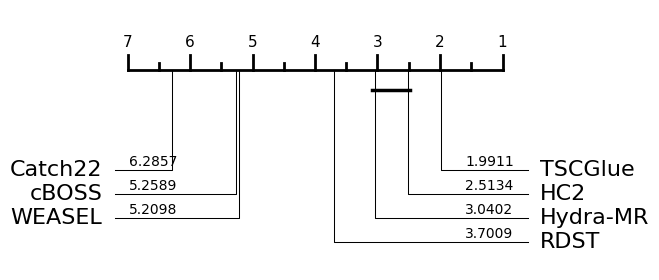

In [23]:
clsf = df_performance_full.rename({'loky-stacker-v10-fm': 'TSCGlue'}).select(['TSCGlue', 'HC2', 'Hydra-MR', 'cBOSS', 'Catch22', 'RDST', 'WEASEL'])
plot_critical_difference(clsf.to_numpy(), clsf.columns)

(<Figure size 600x260 with 1 Axes>, <Axes: >)

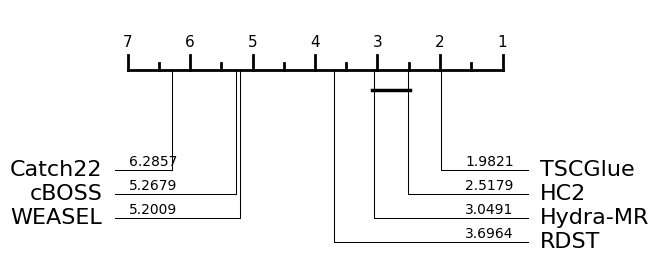

In [24]:
clsf = df_performance_full.rename({'loky-stacker-v10-rstsf-random': 'TSCGlue'}).select(['TSCGlue', 'HC2', 'Hydra-MR', 'cBOSS', 'Catch22', 'RDST', 'WEASEL'])
plot_critical_difference(clsf.to_numpy(), clsf.columns)


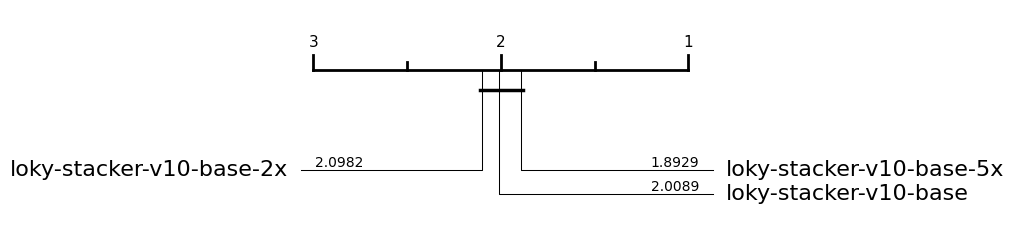

In [ ]:
clsf = df_performance_full.select(['loky-stacker-v10-base-5x', 'loky-stacker-v10-base-2x', 'loky-stacker-v10-base'])
plot_critical_difference(clsf.to_numpy(), clsf.columns)
plt.savefig(f"{directory}/n_repetitions.pdf", bbox_inches='tight', pad_inches=0)



In [26]:
#v = (df_performance_full['loky-stacker-v10-base-2x'] - df_performance_full['HC2']).to_numpy()
#(v>0).sum(), (v<0).sum(), (v==0).sum()

In [27]:
def dataset_stats():

    stats = []
    for dataset in univariate:
        X_train, y_train, X_test, y_test = utils.load_dataset(dataset)
        stats.append(
            {
                "dataset": dataset,
                "n_train": X_train.shape[0],
                "n_test": X_test.shape[0],
                "n_classes": len(np.unique(y_train)),
                "series_length": X_train.shape[2],
            }
        )
    return pl.DataFrame(stats)


stats = dataset_stats()

df_performance_full.join(stats, on='dataset').sort('n_train')

Catch22,FreshPRINCE,HC2,Hydra-MR,MrSQM,Multi-R,PF,RDST,RSF,RSTSF,STC,TS-CHIEF,TSF,WEASEL,cBOSS,dataset,loky-stacker-v10-rstsf-random,multistack-best-stacking,loky-stacker-v10-base-r3,loky-stacker-v10-tabicl,multistack-ridgecv,TSCGlue-17-4-26,loky-stacker-v10-fm,tabicl,rstsf-unsupervised,loky-stacker-v10-base,multirocket-grp,loky-stacker-v10-base-2x,rstsf-combined,rstsf-random,loky-stacker-v7-soft-filter-ridge,rstsf-random-ridge,multistack-best,loky-stacker-v10-base-5x,TSCGlue-3-3-26,multistack-best-base,rstsf-unsupervised-raw,loky-stacker-v9-base-r1,loky-stacker-v10-fm-tsfresh,n_train,n_test,n_classes,series_length
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64
0.908279,0.916993,0.946841,0.950436,0.890741,0.952179,0.956754,0.944989,0.919935,0.937146,0.924619,0.945861,0.940632,0.894553,0.881046,"""DiatomSizeReduction""",0.952179,0.952179,0.952179,0.952179,0.948281,0.952179,0.952179,0.964706,0.919432,0.952179,0.950327,0.952179,0.944756,0.944444,0.952179,0.912092,0.954248,0.952896,0.952179,0.947861,0.936126,0.952179,0.964597,16,306,4,345
0.986613,0.999866,0.999331,0.984739,0.857028,0.996252,1.0,0.965194,1.0,1.0,0.905087,1.0,1.0,1.0,0.998527,"""InsectEPGSmallTrain""",1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.988526,1.0,0.990897,1.0,1.0,1.0,1.0,0.999197,0.996701,1.0,1.0,0.996305,0.76367,1.0,1.0,17,249,3,601
0.851667,0.881667,0.911667,0.911667,0.963333,0.895,0.86,0.926667,0.875,0.885,0.951667,0.958333,0.823333,0.92,0.96,"""BeetleFly""",0.906667,0.893333,0.91,0.883333,0.916667,0.906667,0.908333,0.753333,0.879545,0.901667,0.9,0.896667,0.882692,0.885,0.895,0.846667,0.907407,0.901667,0.895,0.908333,0.85625,0.906667,0.871429,20,20,2,512
0.888333,0.923333,0.946667,0.91,0.958333,0.89,0.903333,0.913333,0.833333,0.963333,0.915,0.963333,0.821667,0.906667,0.981667,"""BirdChicken""",0.958333,0.958929,0.931667,0.941667,0.965,0.958333,0.961667,0.726667,0.85,0.938333,0.896667,0.938333,0.953704,0.943333,0.941667,0.911667,0.936207,0.92931,0.936667,0.927273,0.836364,0.936667,0.928571,20,20,2,512
0.892323,0.972789,0.970068,0.965792,0.95345,0.966569,0.948019,0.968416,0.883479,0.975607,0.955102,0.961836,0.954227,0.939456,0.942857,"""Chinatown""",0.974247,0.973437,0.974927,0.973081,0.975948,0.974247,0.974927,0.972886,0.945374,0.973761,0.86482,0.974344,0.973411,0.976579,0.97551,0.959086,0.9695,0.973567,0.975802,0.969123,0.969388,0.974733,0.971574,20,343,2,24
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.792152,0.847708,0.843706,0.859402,0.816861,0.857964,0.829099,0.829099,0.817211,0.841414,0.833877,0.82533,0.811772,0.811305,0.780109,"""PhalangesOutlinesCorrect""",0.863092,0.863442,0.862626,0.864569,0.862334,0.863092,0.863598,0.868221,0.779598,0.863287,0.832906,0.864763,0.830293,0.84122,0.862587,0.809207,0.863345,0.862428,0.862937,0.854033,0.793706,0.863015,0.862138,1800,858,2,80
0.908636,1.0,0.953712,0.955354,0.95,0.954141,0.850025,0.949242,0.876515,0.977803,0.934242,0.947399,0.81846,0.960657,0.908939,"""FordA""",0.982399,0.984848,0.981136,0.985328,0.982416,0.982399,0.981338,0.902525,0.937689,0.981338,0.927904,0.981034,0.981313,0.977803,0.981414,0.982247,0.984848,0.981902,0.981414,0.978693,0.968182,0.981237,1.0,3601,1320,2,500
0.867778,0.9207,0.933868,0.931193,0.922798,0.929671,0.839383,0.928601,0.85786,0.922593,0.9193,0.919465,0.785267,0.928354,0.883086,"""FordB""",0.937778,0.936741,0.939959,0.940864,0.940947,0.937778,0.939547,0.862757,0.913653,0.940535,0.895967,0.941209,0.926194,0.920988,0.940741,0.920741,0.940494,0.94127,0.940453,0.931054,0.890809,0.940206,0.931893,3636,810,2,500


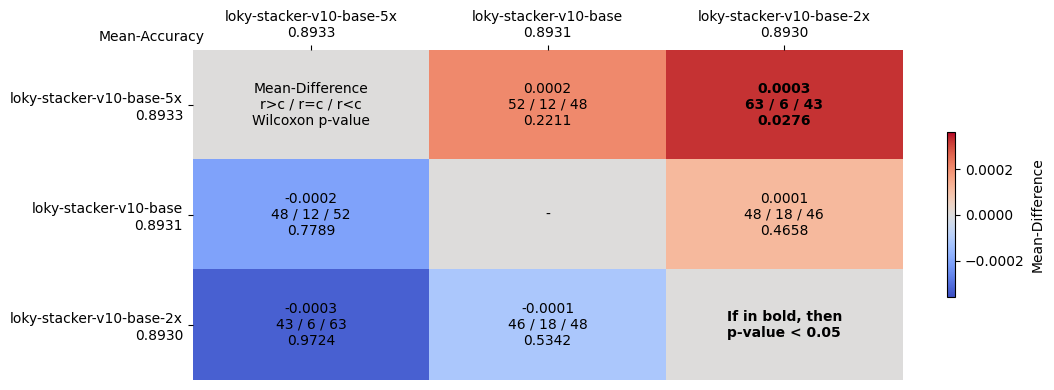

In [28]:
from aeon.visualisation import create_multi_comparison_matrix

create_multi_comparison_matrix(clsf.to_pandas())
plt.savefig(f"{directory}/multi_comparison_matrix.pdf", bbox_inches='tight', pad_inches=0)

In [29]:
def plot_acc_diff_vs_size(df, m1, m2):
    data = df.join(stats, on='dataset').with_columns(pl.col('n_train').log().alias('n_train_log')).sort('n_train')
    plt.scatter(data['n_train'], data[m1]-data[m2], s=10)
    plt.xlabel('Training Set Size')
    plt.ylabel(f'Accuracy Difference ({m1} − {m2})')
    plt.xscale('log')
    plt.grid()
    plt.axhline(0, color='black', linewidth=0.8)
    ylim = plt.gca().get_ylim()
    plt.axhspan(0, ylim[1], alpha=0.08, color='green')
    plt.axhspan(ylim[0], 0, alpha=0.08, color='red')
    plt.text(0.98, 0.95, f'{m1} better', transform=plt.gca().transAxes, ha='right', va='top', fontsize=9, color='green')
    plt.text(0.98, 0.05, f'{m2} better', transform=plt.gca().transAxes, ha='right', va='bottom', fontsize=9, color='red')
    plt.ylim(ylim)


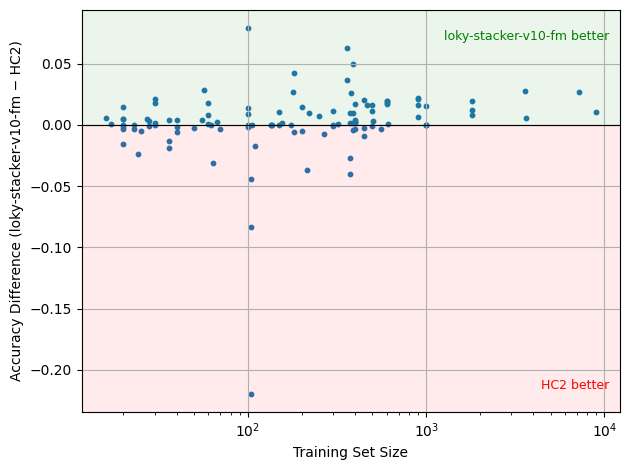

In [30]:
plot_acc_diff_vs_size(df_performance_full, 'loky-stacker-v10-fm', 'HC2')


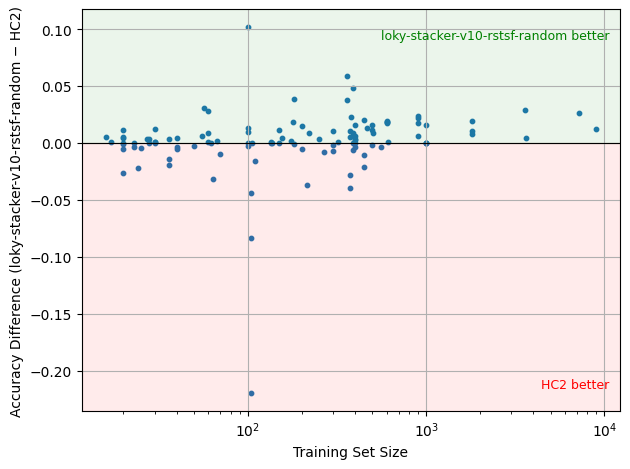

In [31]:
plot_acc_diff_vs_size(df_performance_full, 'loky-stacker-v10-rstsf-random', 'HC2')

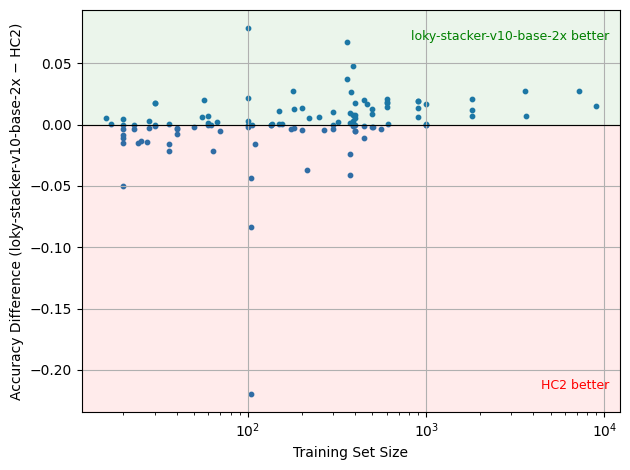

In [32]:
plot_acc_diff_vs_size(df_performance_full, 'loky-stacker-v10-base-2x', 'HC2')


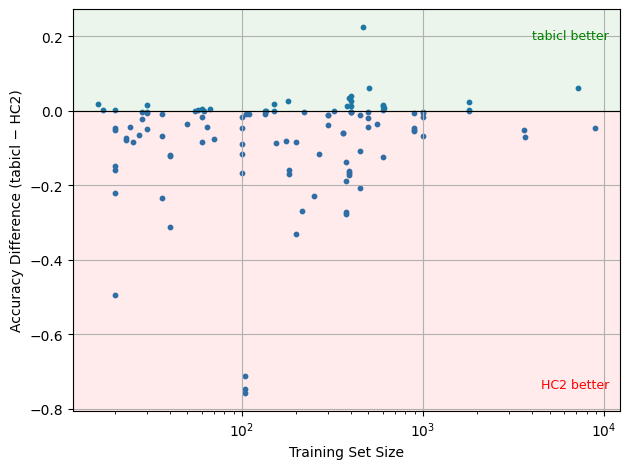

In [33]:
plot_acc_diff_vs_size(df_performance_full, 'tabicl', 'HC2')


In [34]:
# plot_acc_diff_vs_size(df_performance_full, 'mantis+chronos2+diff-ridgecv', 'HC2')

In [35]:
#plot_acc_diff_vs_size(df_performance_full, 'mantis+chronos2+diff-ridgecv', 'loky-stacker-v10-base-5x')

In [36]:
#plot_acc_diff_vs_size(df_performance_full, 'loky-stacker-v7-soft-ridge', 'loky-stacker-v7-soft-rf')

/tmp/ipykernel_2384676/1847863942.py:3: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(f"{directory}/stacking_best.pdf", bbox_inches='tight', pad_inches=0)
/tmp/ipykernel_2384676/1847863942.py:3: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(f"{directory}/stacking_best.pdf", bbox_inches='tight', pad_inches=0)
/home/petelin/TSCGlue/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


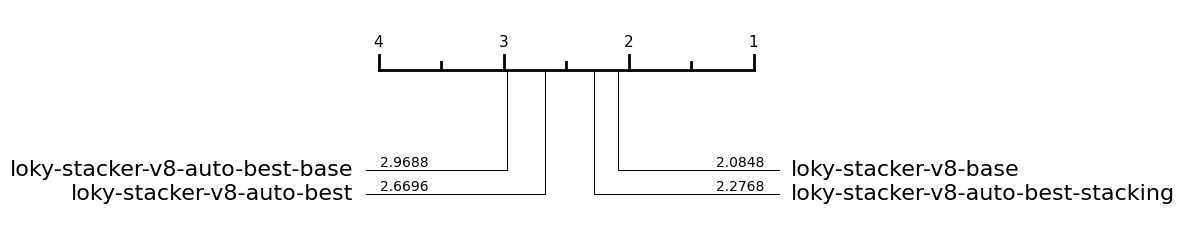

In [37]:
clsf = df_performance_full_saved.select(['loky-stacker-v8-base', 'loky-stacker-v8-auto-best', 'loky-stacker-v8-auto-best-base', 'loky-stacker-v8-auto-best-stacking'])
plot_critical_difference(clsf.to_numpy(), clsf.columns)
plt.savefig(f"{directory}/stacking_best.pdf", bbox_inches='tight', pad_inches=0)



In [38]:
l = df_performance_full_saved.select(['hivecotev2-1h-j8', 'loky-stacker-v10-rstsf-random']).sort('hivecotev2-1h-j8')
l1 = l['hivecotev2-1h-j8'].to_numpy()
l2 = l['loky-stacker-v10-rstsf-random'].to_numpy()

In [39]:
l

hivecotev2-1h-j8,loky-stacker-v10-rstsf-random
f64,f64
null,0.948198
0.370077,0.367423
0.508727,0.632606
0.530303,0.562987
0.561688,0.57619
…,…
1.0,1.0
1.0,0.996926
1.0,1.0


In [40]:
np.sum(df_performance_full_saved['hivecotev2-1h-j8'].to_numpy()>df_performance_full_saved['loky-stacker-v10-rstsf-random'].to_numpy()), np.sum(l1==l2), np.sum(df_performance_full_saved['hivecotev2-1h-j8'].to_numpy()<df_performance_full_saved['loky-stacker-v10-rstsf-random'].to_numpy()), 

(np.int64(36), np.int64(7), np.int64(68))

In [41]:
df_performance_full_saved

Arsenal,BOSS,CIF,CNN,Catch22,DrCIF,EE,FreshPRINCE,HC1,HC2,Hydra-MR,Hydra,InceptionT,Mini-R,MrSQM,Multi-R,PF,RDST,RISE,ROCKET,RSF,RSTSF,ResNet,STC,ShapeDTW,Signatures,TDE,TS-CHIEF,TSF,TSFresh,WEASEL-D,WEASEL,cBOSS,1NN-DTW,dataset,loky-stacker-v10-rstsf-random,multirocket-f32,…,rstsf-unsupervised,loky-stacker-v10-base,chronos2-ridgecv,mydummy,loky-stacker-v8-base-r3,multirocket-grp,loky-stacker-v7,loky-stacker-v8-auto-best-stacking,chronos2,mr-hydra-kbest-10000,mantis+chronos2+diff-ridgecv,loky-stacker-v10-base-2x,mantis+chronos2-ridgecv,rstsf-combined,loky-stacker-v6-soft-rf,rstsf-random,loky-stacker-v7-soft-filter-ridge,rstsf-random-ridge,multistack-best,loky-stacker-v7-soft-et,loky-stacker-v10-base-5x,mr-hydra-kbest-30000,loky-stacker-v7-soft-ridge,loky-stacker-v9-base-r2,loky-stacker-v8-auto-best,TSCGlue-3-3-26,mymrhydra,multistack-best-base,rstsf-unsupervised-raw,loky-stacker-v9-base-r1,loky-stacker-v10-fm-tsfresh,rstsf-unsupervised-ridge,loky-stacker-v9-base-r3,hivecotev2-1h-j8,rstsf-combined-ridge,hivecotev2-4h-j8,mantis+chronos2-rf
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.987416,0.996653,1.0,1.0,0.996653,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.968139,1.0,1.0,1.0,0.996787,0.986479,1.0,1.0,1.0,0.976841,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,"""InsectEPGRegularTrain""",1.0,1.0,…,0.999476,1.0,0.968541,0.473896,1.0,0.999331,1.0,1.0,0.969277,1.0,0.999866,1.0,1.0,1.0,1.0,1.0,1.0,0.999866,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.955458,1.0,1.0,0.996787,1.0,1.0,null,null,1.0
0.908814,0.966026,0.774679,0.127404,0.886538,0.834135,0.620833,0.870513,0.967628,0.979327,0.926923,0.95016,0.933333,0.959615,0.973878,0.926603,0.715705,0.932372,0.804968,0.907532,0.801603,0.865865,0.953686,0.908333,0.303846,0.275641,0.980128,0.96891,0.392468,0.875801,0.957692,0.978365,0.965705,0.456891,"""PigArtPressure""",0.935417,0.927724,…,0.596795,0.935417,0.412821,0.019231,0.93563,0.920032,0.935417,0.935417,0.415064,0.976763,0.825,0.935417,0.688622,0.759348,0.935417,0.731731,0.935417,0.373878,0.935096,0.935417,0.936174,0.969231,0.935417,0.913194,0.935417,0.935417,0.935417,0.936923,0.200175,0.934776,0.930288,0.450321,0.879808,0.988782,null,1.0,null
0.891667,0.98,0.868333,0.705,0.888333,0.951667,0.836667,0.923333,0.965,0.946667,0.91,0.926667,0.951667,0.918333,0.958333,0.89,0.903333,0.913333,0.861667,0.9,0.833333,0.963333,0.945,0.915,0.69,0.691667,0.968333,0.963333,0.821667,0.608333,0.933333,0.906667,0.981667,0.84,"""BirdChicken""",0.958333,0.89,…,0.85,0.938333,0.95,0.5,0.927778,0.896667,0.923333,0.94,0.95,0.908333,0.961667,0.938333,0.973333,0.953704,0.941667,0.943333,0.941667,0.911667,0.936207,0.948333,0.92931,0.905,0.933333,0.94,0.928333,0.936667,0.896667,0.927273,0.836364,0.936667,0.928571,0.896667,0.925,0.95,0.9,0.95,null
0.621875,0.605208,0.6109375,0.581771,0.553646,0.5984375,0.580208,0.6015625,0.621354,0.632292,0.630729,0.616146,0.625,0.608854,0.6421875,0.611458,0.574479,0.638021,0.583854,0.614583,0.578125,0.590104,0.596875,0.6421875,0.536458,0.572917,0.578646,0.597396,0.607292,0.59375,0.603125,0.627083,0.586458,0.5671875,"""Herring""",0.600521,0.607292,…,0.651042,0.603646,0.556771,0.59375,0.61489,0.619271,0.599479,0.5921875,0.55,0.619792,0.5703125,0.610417,0.580208,0.611875,0.590104,0.6,0.606771,0.603646,0.590199,0.59375,0.603646,0.607292,0.6046875,0.6078125,0.598958,0.607292,0.610417,0.598125,0.613636,0.6,0.621094,0.597656,0.567708,0.6328125,0.59375,null,0.546875
0.714489,0.792356,0.694222,0.499111,0.705422,0.741689,0.6824,0.747467,0.811733,0.827022,0.748533,0.732356,0.758933,0.707822,0.785067,0.737778,0.672356,0.750222,0.653067,0.731911,0.666489,0.728444,0.786844,0.787378,0.451378,0.604889,0.8512,0.726844,0.615911,0.753333,0.771111,0.724267,0.794756,0.571467,"""RefrigerationDevices""",0.787556,

In [42]:
!uv pip list

Using Python 3.13.2 environment at: /home/petelin/TSCGlue/.venv
Package                   Version     Editable project location
------------------------- ----------- -------------------------
accelerate                1.12.0
aeon                      1.3.0
aiohappyeyeballs          2.6.1
aiohttp                   3.13.3
aiosignal                 1.4.0
anyio                     4.12.1
argon2-cffi               25.1.0
argon2-cffi-bindings      25.1.0
arrow                     1.4.0
asttokens                 3.0.1
async-lru                 2.2.0
attrs                     25.4.0
awscli                    1.44.44
babel                     2.18.0
beautifulsoup4            4.14.3
bleach                    6.3.0
bokeh                     3.8.2
boto3                     1.42.54
botocore                  1.42.54
catboost                  1.2.10
certifi                   2026.1.4
cffi                      2.0.0
charset-normalizer        3.4.4
chronos-forecasting       2.2.2
click                 